# Scoping - User Input & Brief Generation

The goal of the scoping process is to collect as much relevant information from the User as needed for the research. 

**User Input** *Every research starts with a user inquiry and additional input provided to define scope of the inquiry*

**Brief Generation** *When all the relevant information is gathered, a brief is generated to perform the research.*

Here is our overall research flow:

In [ ]:
from IPython.display import Image


: 

In [ ]:
Image("../images/graph_scoping.png")

: 

## Imports

In [ ]:
import sys 

sys.path.insert(0,"../code")


In [4]:
%load_ext autoreload
%autoreload 2

In [5]:
import utils_display
from utils_import import *
import prompts
import rich
import utils
from IPython.display import Image


🔭 OpenTelemetry Tracing Details 🔭
|  Phoenix Project: npatta01
|  Span Processor: SimpleSpanProcessor
|  Collector Endpoint: llm-tracing.np-training.dev:4317
|  Transport: gRPC
|  Transport Headers: {}
|  
|  Using a default SpanProcessor. `add_span_processor` will overwrite this default.
|  
|  ⚠️ WARNING: It is strongly advised to use a BatchSpanProcessor in production environments.
|  
|  `register` has set this TracerProvider as the global OpenTelemetry default.
|  To disable this behavior, call `register` with `set_global_tracer_provider=False`.



In [6]:
from datetime import datetime
from typing_extensions import Literal

from langchain_core.messages import HumanMessage, AIMessage, get_buffer_string
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command
from langchain_openai import ChatOpenAI

### LLM Prompt for iteratively interacting with the user and ask clarifying questions.

In [7]:
utils_display.show_prompt(prompts.clarify_with_user_instructions,"clarify_with_user_instructions")

╭──────────────────────────────────────── clarify_with_user_instructions ─────────────────────────────────────────╮
│                                                                                                                 │
│  You are an expert research assistant. You will be given the conversation so far between the user and           │
│  assistant:                                                                                                     │
│  <Messages>                                                                                                     │
│  {messages}                                                                                                     │
│  </Messages>                                                                                                    │
│                                                                                                                 │
│  Date: {date}                                                                                                   │
│                                                                                                                 │
│  Task: Decide whether you need additional information to start research. Be conservative: only ask if           │
│  absolutely necessary. Before asking a new question, check if that question was already answered or not. If     │
│  not, only then re-ask that question.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
│  If you ask a question, collect all missing high-level items in one or more messages using this short bullet    │
│  list format (use markdown bullets so it renders nicely if viewed in markdown):                                 │
│  - Goal: (what should the research achieve?)                                                                    │
│  - Scope: (topics, geography, timeframe)                                                                        │
│  - Success criteria: (what will make the research useful?)                                                      │
│  - Constraints: (budget, languages, sources to include/avoid, deadlines)                                        │
│  - Preferred sources or formats: (links, types of sources, output format)                                       │
│                                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

### State

In [ ]:
import operator
from typing import Annotated, Sequence
from typing_extensions import Optional
from langchain_core.messages import BaseMessage
from pydantic import BaseModel, Field


class AgentState(BaseModel):
    """
    State for the research agent scoping workflow.
    """

    # Research brief generated from user conversation history
    research_brief: Optional[str] = None
    # messages exchanged in the conversation
    messages: Annotated[Sequence[BaseMessage], operator.add] = []

## Structured Output Schemas

In [9]:
class ClarifyWithUserOutput(BaseModel):
    """Schema for user clarification decision and questions."""
    
    need_clarification: bool = Field(
        description="Whether the user needs to be asked a clarifying question.",
    )
    question: str = Field(
        description="A question to ask the user to clarify the report scope",
    )
    verification: str = Field(
        description="Verify message that we will start research after the user has provided the necessary information.",
    )


class ResearchQuestionOutput(BaseModel):
    """Schema for structured research brief generation."""
    
    research_brief: str = Field(
        description="A research question that will be used to guide the research.",
    )

In [10]:
# Initialize model
model = ChatOpenAI(
    model="gpt-4.1",
    base_url=OPENAI_BASE_URL,
    temperature=0.0,
    #max_tokens=512,
)

## Workflow Steps

In [ ]:
def clarify_with_user(state: AgentState) -> Command[Literal["write_research_brief", "__end__"]]:
    """
    Determine if the user's request contains sufficient information to proceed with research, or if a clarifying question is needed.
    """
    # Set up structured output model
    structured_output_model = model.with_structured_output(ClarifyWithUserOutput)

    # Invoke the model with clarification instructions
    response = structured_output_model.invoke([
        HumanMessage(content=prompts.clarify_with_user_instructions.format(
            messages=get_buffer_string(messages=state.messages), 
            date=utils.get_today_str()
        ))
    ])
    
    # Route based on clarification need
    if response.need_clarification:
        return Command(
            goto=END, 
            update={"messages": [AIMessage(content=response.question)]}
        )
    else:
        return Command(
            goto="write_research_brief", 
            update={"messages": [AIMessage(content=response.verification)]}
        )

def write_research_brief(state: AgentState):
    """
    Transform the conversation history into a comprehensive research brief.
    """
    # Set up structured output model
    structured_output_model = model.with_structured_output(ResearchQuestionOutput)
    
    # Generate research brief from conversation history
    response = structured_output_model.invoke([
        HumanMessage(content=prompts.transform_messages_into_research_topic.format(
            messages=get_buffer_string(state.messages),
            date=utils.get_today_str()
        ))
    ])
    
    return {
        "research_brief": response.research_brief,
        "messages": [HumanMessage(content=f"{response.research_brief}.")]
    }



## Graph

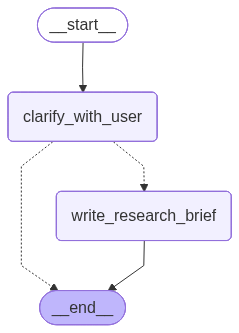

In [ ]:
scope_research_builder = StateGraph(AgentState)

# Add workflow nodes
scope_research_builder.add_node("clarify_with_user", clarify_with_user)
scope_research_builder.add_node("write_research_brief", write_research_brief)

# Add workflow edges
scope_research_builder.add_edge(START, "clarify_with_user")
scope_research_builder.add_edge("write_research_brief", END)

# Compile the workflow
graph_scope_research = scope_research_builder.compile()
graph_scope_research

## Start the scoping with a user inquiry

In [13]:
query = "What is the best coffee shop in seattle."

## Scenario: Incomplete user input requiring clarification

In [ ]:
result = graph_scope_research.invoke({"messages": [HumanMessage(content=query)]})
utils_display.format_messages(result['messages'])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ What is the best coffee shop in seattle.                                                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Could you clarify what you mean by 'best'? Are you looking for the best coffee based on taste, atmosphere,      │
│ popularity, or something else? Also, are you interested in a specific neighborhood in Seattle or the city as a  │
│ whole?                                                                                                          │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Image("../images/trace_scoping_incomplete_a.png")

### Let's provide additional input to clarify

In [ ]:
human_answer = "Quality of the coffee bean and the atmosphere of the shop are the two most important factors for me."
result["messages"] += [HumanMessage(content=human_answer)]
result = graph_scope_research.invoke(result["messages"] += [HumanMessage(content=human_answer)])

utils_display.format_messages(result['messages'])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ What is the best coffee shop in seattle.                                                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Could you clarify what you mean by 'best'? Are you looking for the best coffee based on taste, atmosphere,      │
│ popularity, or something else? Also, are you interested in a specific neighborhood in Seattle or the city as a  │
│ whole?                                                                                                          │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Quality of the coffee bean and the atmosphere of the shop are the two most important factors for me.            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Thank you for clarifying your priorities. I will now research the best coffee shops in Seattle based on the     │
│ quality of their coffee beans and the atmosphere of the shop.                                                   │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ I am researching the best coffee shop in Seattle, prioritizing the quality of the coffee bean and the           │
│ atmosphere of the shop. The focus should be on establishments known for exceptional coffee and a great in-shop  │
│ experience. Open considerations: specific neighborhoods of interest, preferred style of atmosphere (e.g., cozy, │
│ modern, lively), and whether to consider chains or only independent shops..                                     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [ ]:
result['research_brief']

{'research_brief': 'I am researching the best coffee shop in Seattle, prioritizing the quality of the coffee bean and the atmosphere of the shop. The focus should be on establishments known for exceptional coffee and a great in-shop experience. Open considerations: specific neighborhoods of interest, preferred style of atmosphere (e.g., cozy, modern, lively), and whether to consider chains or only independent shops.',
 'messages': [HumanMessage(content='What is the best coffee shop in seattle.', additional_kwargs={}, response_metadata={}),
  AIMessage(content="Could you clarify what you mean by 'best'? Are you looking for the best coffee based on taste, atmosphere, popularity, or something else? Also, are you interested in a specific neighborhood in Seattle or the city as a whole?", additional_kwargs={}, response_metadata={}),
  HumanMessage(content='Quality of the coffee bean and the atmosphere of the shop are the two most important factors for me.', additional_kwargs={}, response_met

In [ ]:
result['research_brief']

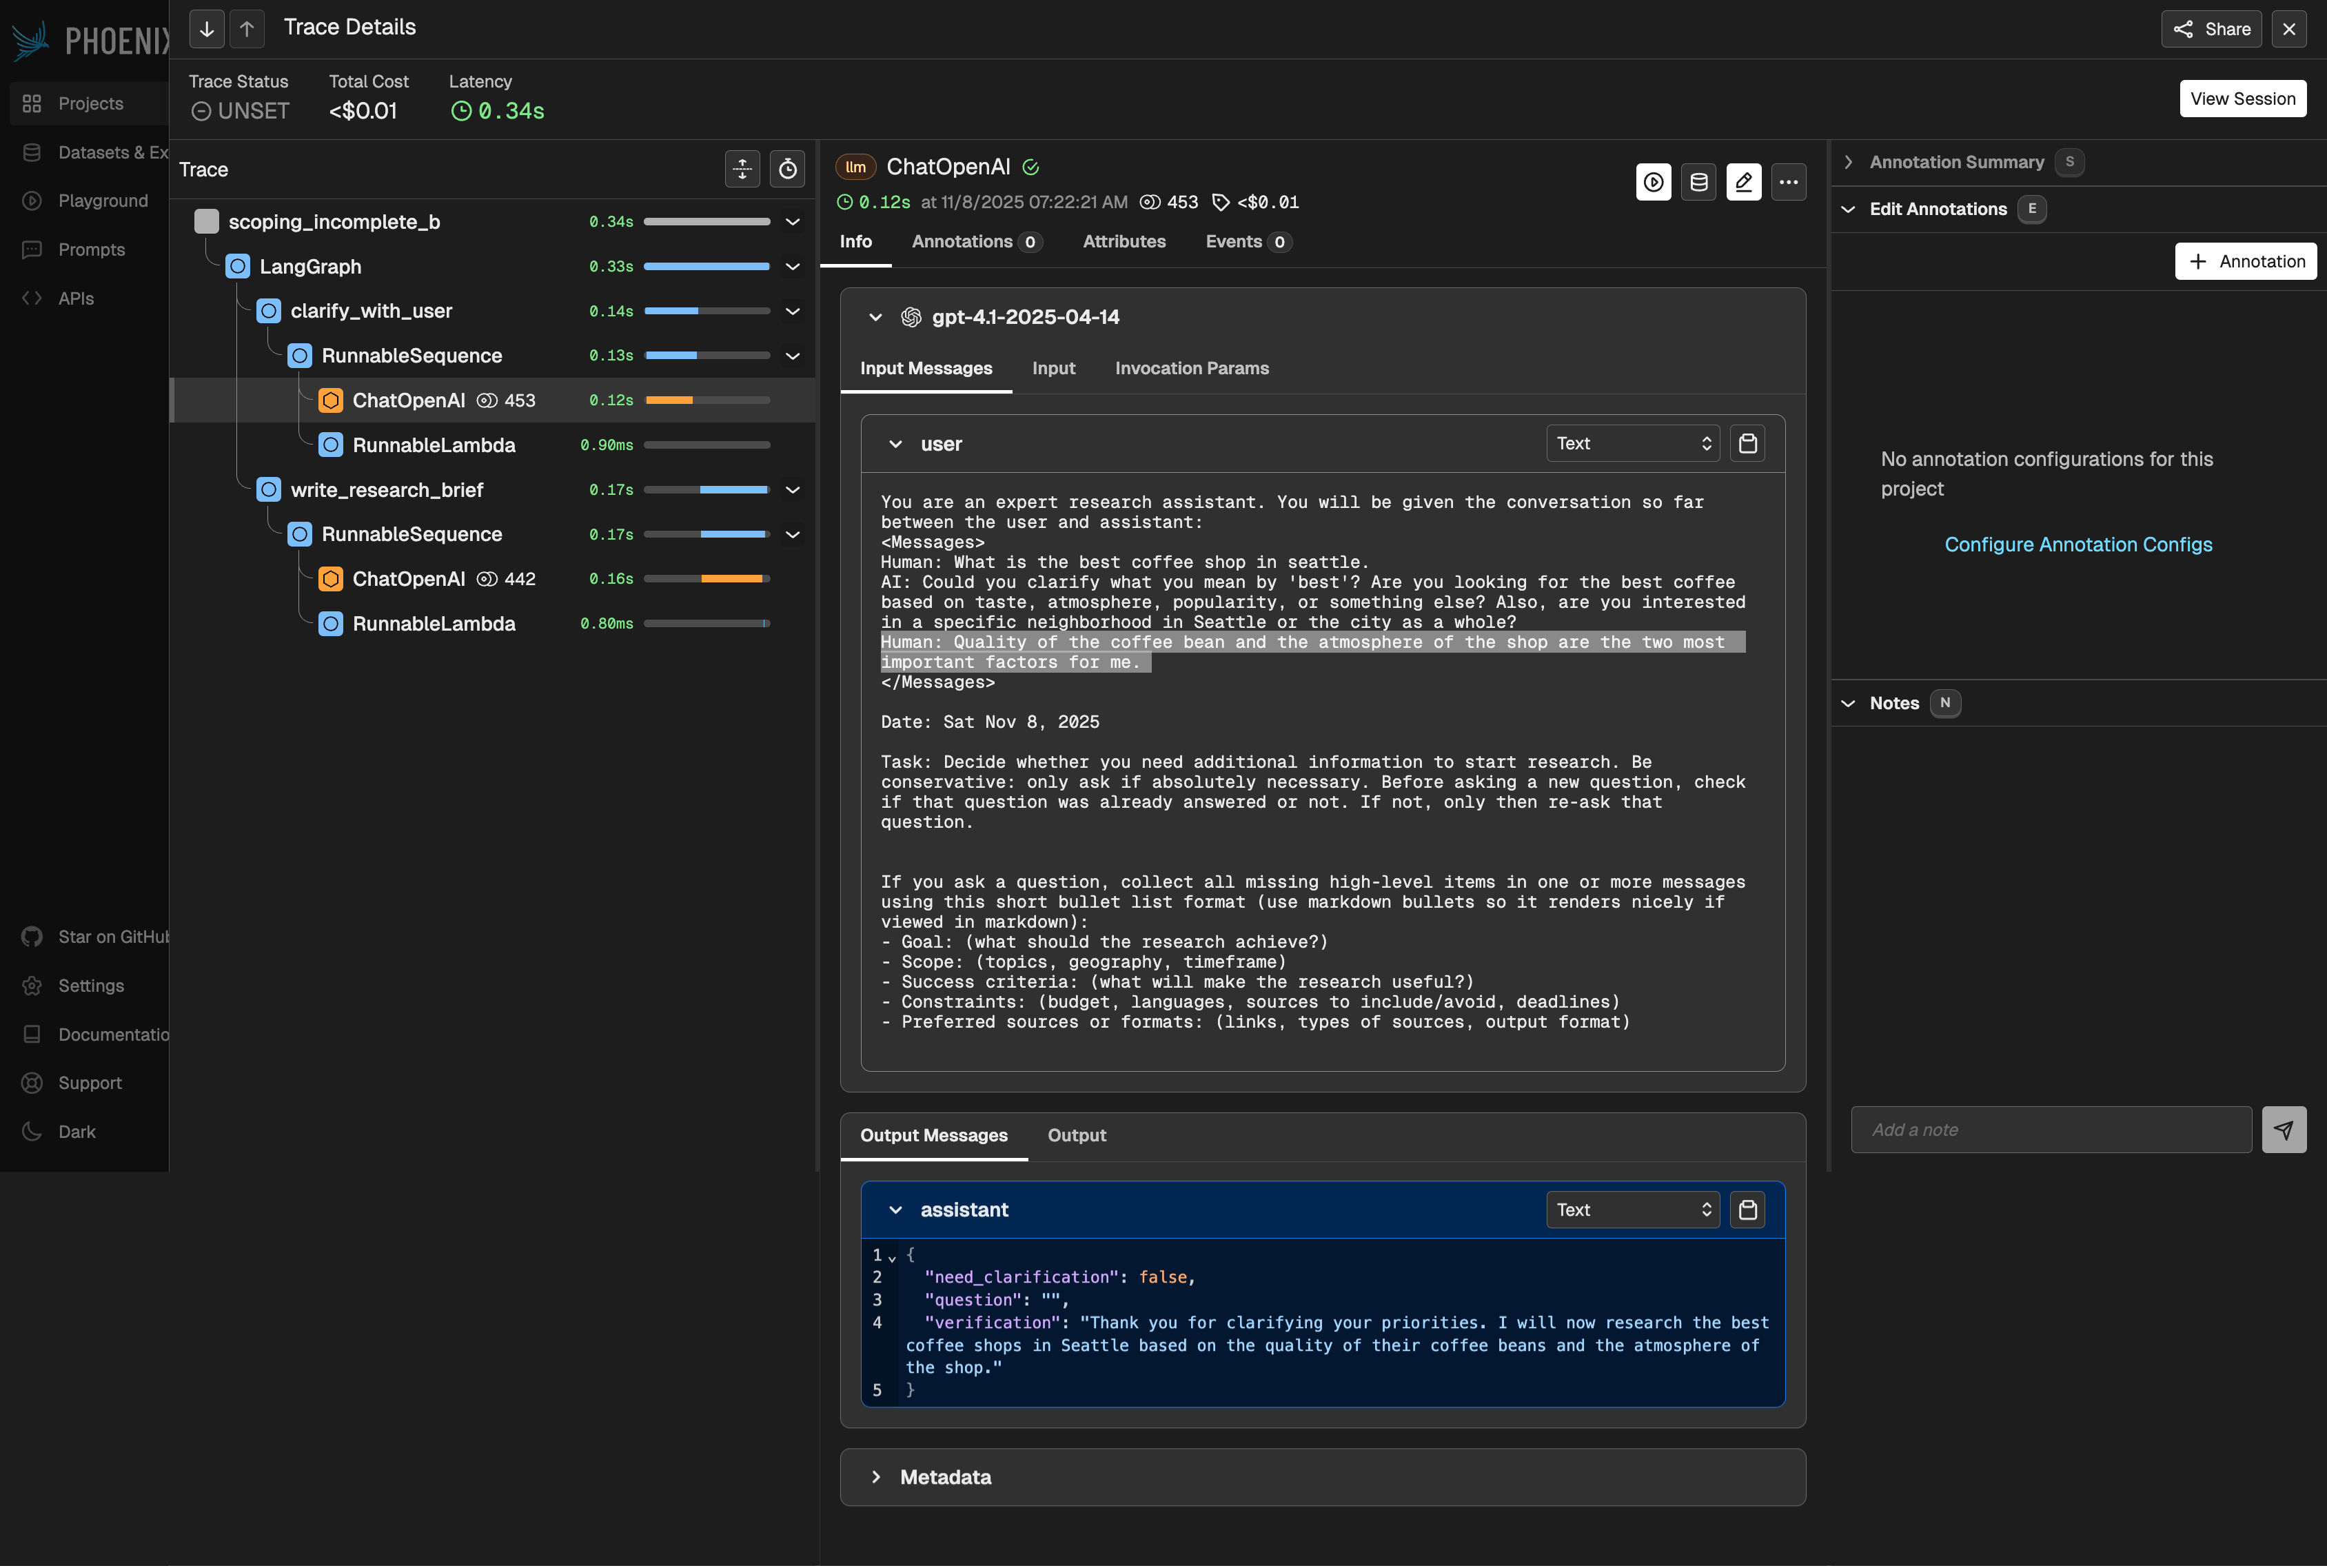

In [17]:
Image("../images/trace_scoping_incomplete_b_clarify.png")

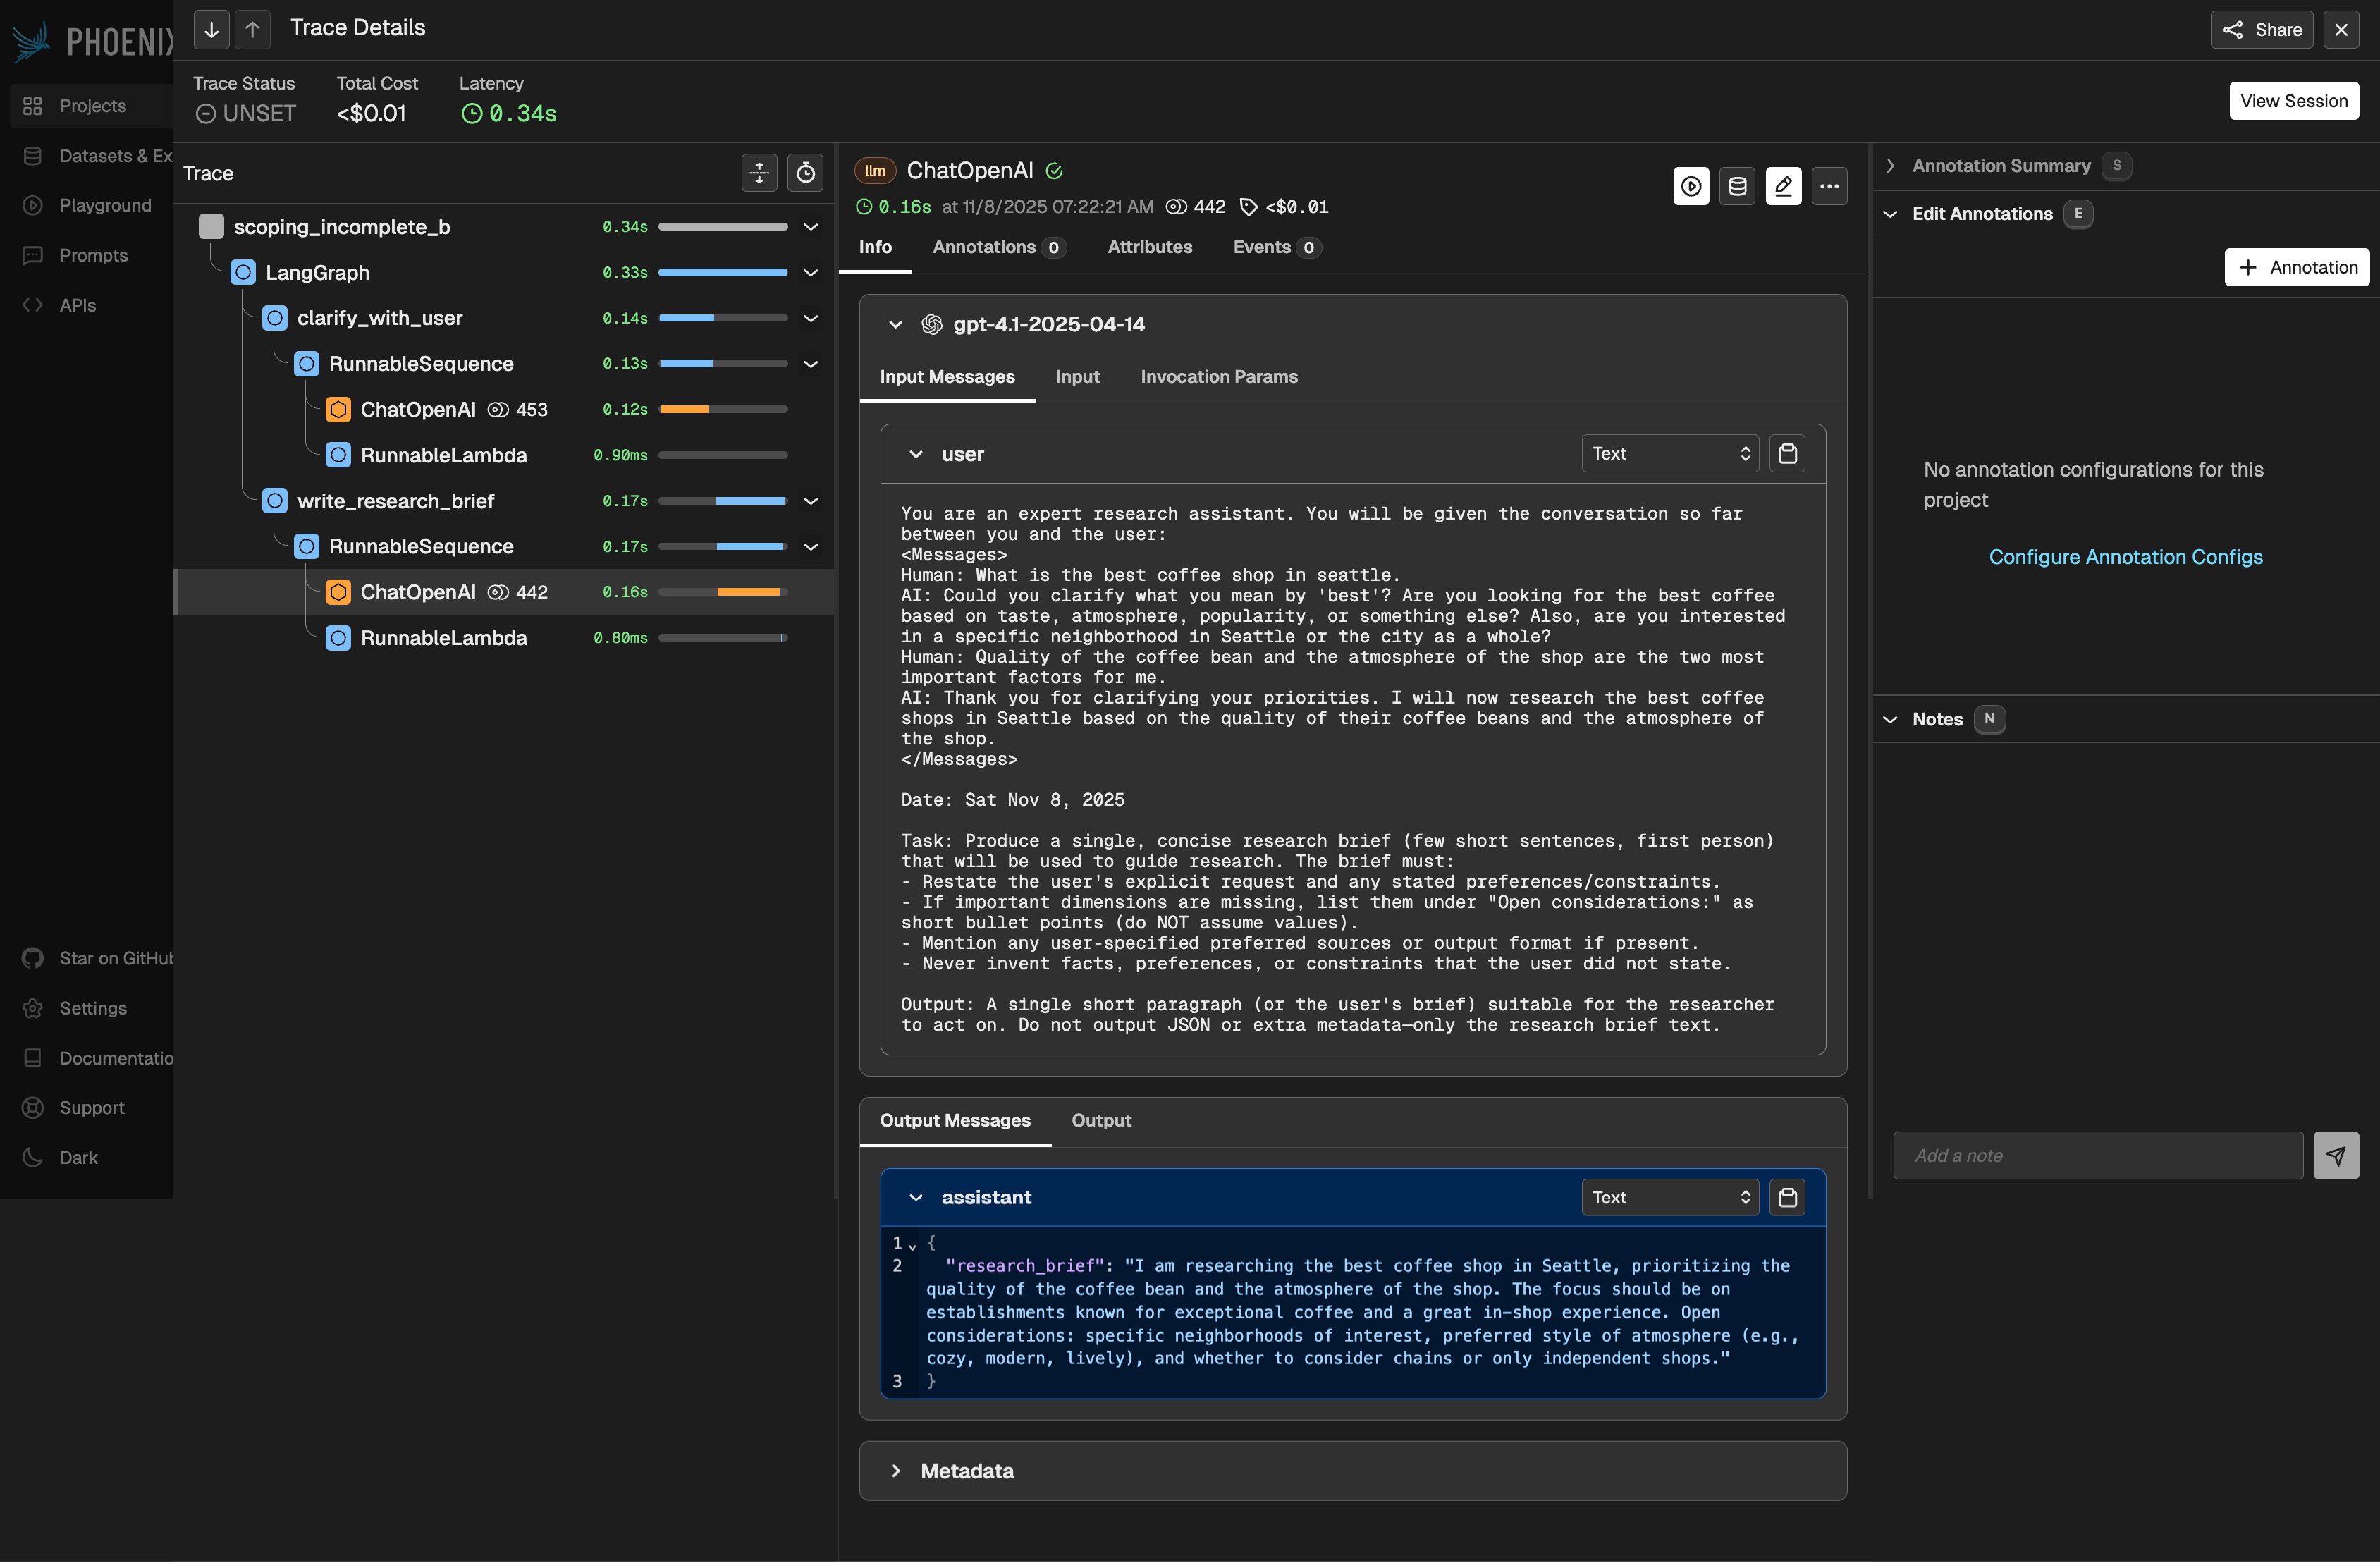

In [18]:
Image("../images/trace_scoping_incomplete_b_brief.png")

### Scenario: User provided full context not requiring clarification

In [ ]:
query = "I am looking for best coffee shop in and around Seattle. I am interested in independent coffee shops, but chains are acceptable."

In [ ]:

result = graph_scope_research.invoke({"messages": [HumanMessage(content=query)]})


utils_display.format_messages(result['messages'])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ I am looking for best coffee shop in and around Seattle. I am interested in independent coffee shops, but       │
│ chains are acceptable.                                                                                          │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Thank you for the details provided. I have enough information to begin researching the best independent and     │
│ chain coffee shops in and around Seattle.                                                                       │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ I am researching the best coffee shops in and around Seattle, with a focus on independent coffee shops but also │
│ considering chains as acceptable options. Open considerations: specific criteria for 'best' (e.g., coffee       │
│ quality, ambiance, location, specialty drinks), preferred neighborhoods or areas, and any particular amenities  │
│ or features of interest..                                                                                       │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [21]:
rich.print(result["research_brief"])

I am researching the best coffee shops in and around Seattle, with a focus on independent coffee shops but also 
considering chains as acceptable options. Open considerations: specific criteria for 'best' (e.g., coffee quality, 
ambiance, location, specialty drinks), preferred neighborhoods or areas, and any particular amenities or features 
of interest.

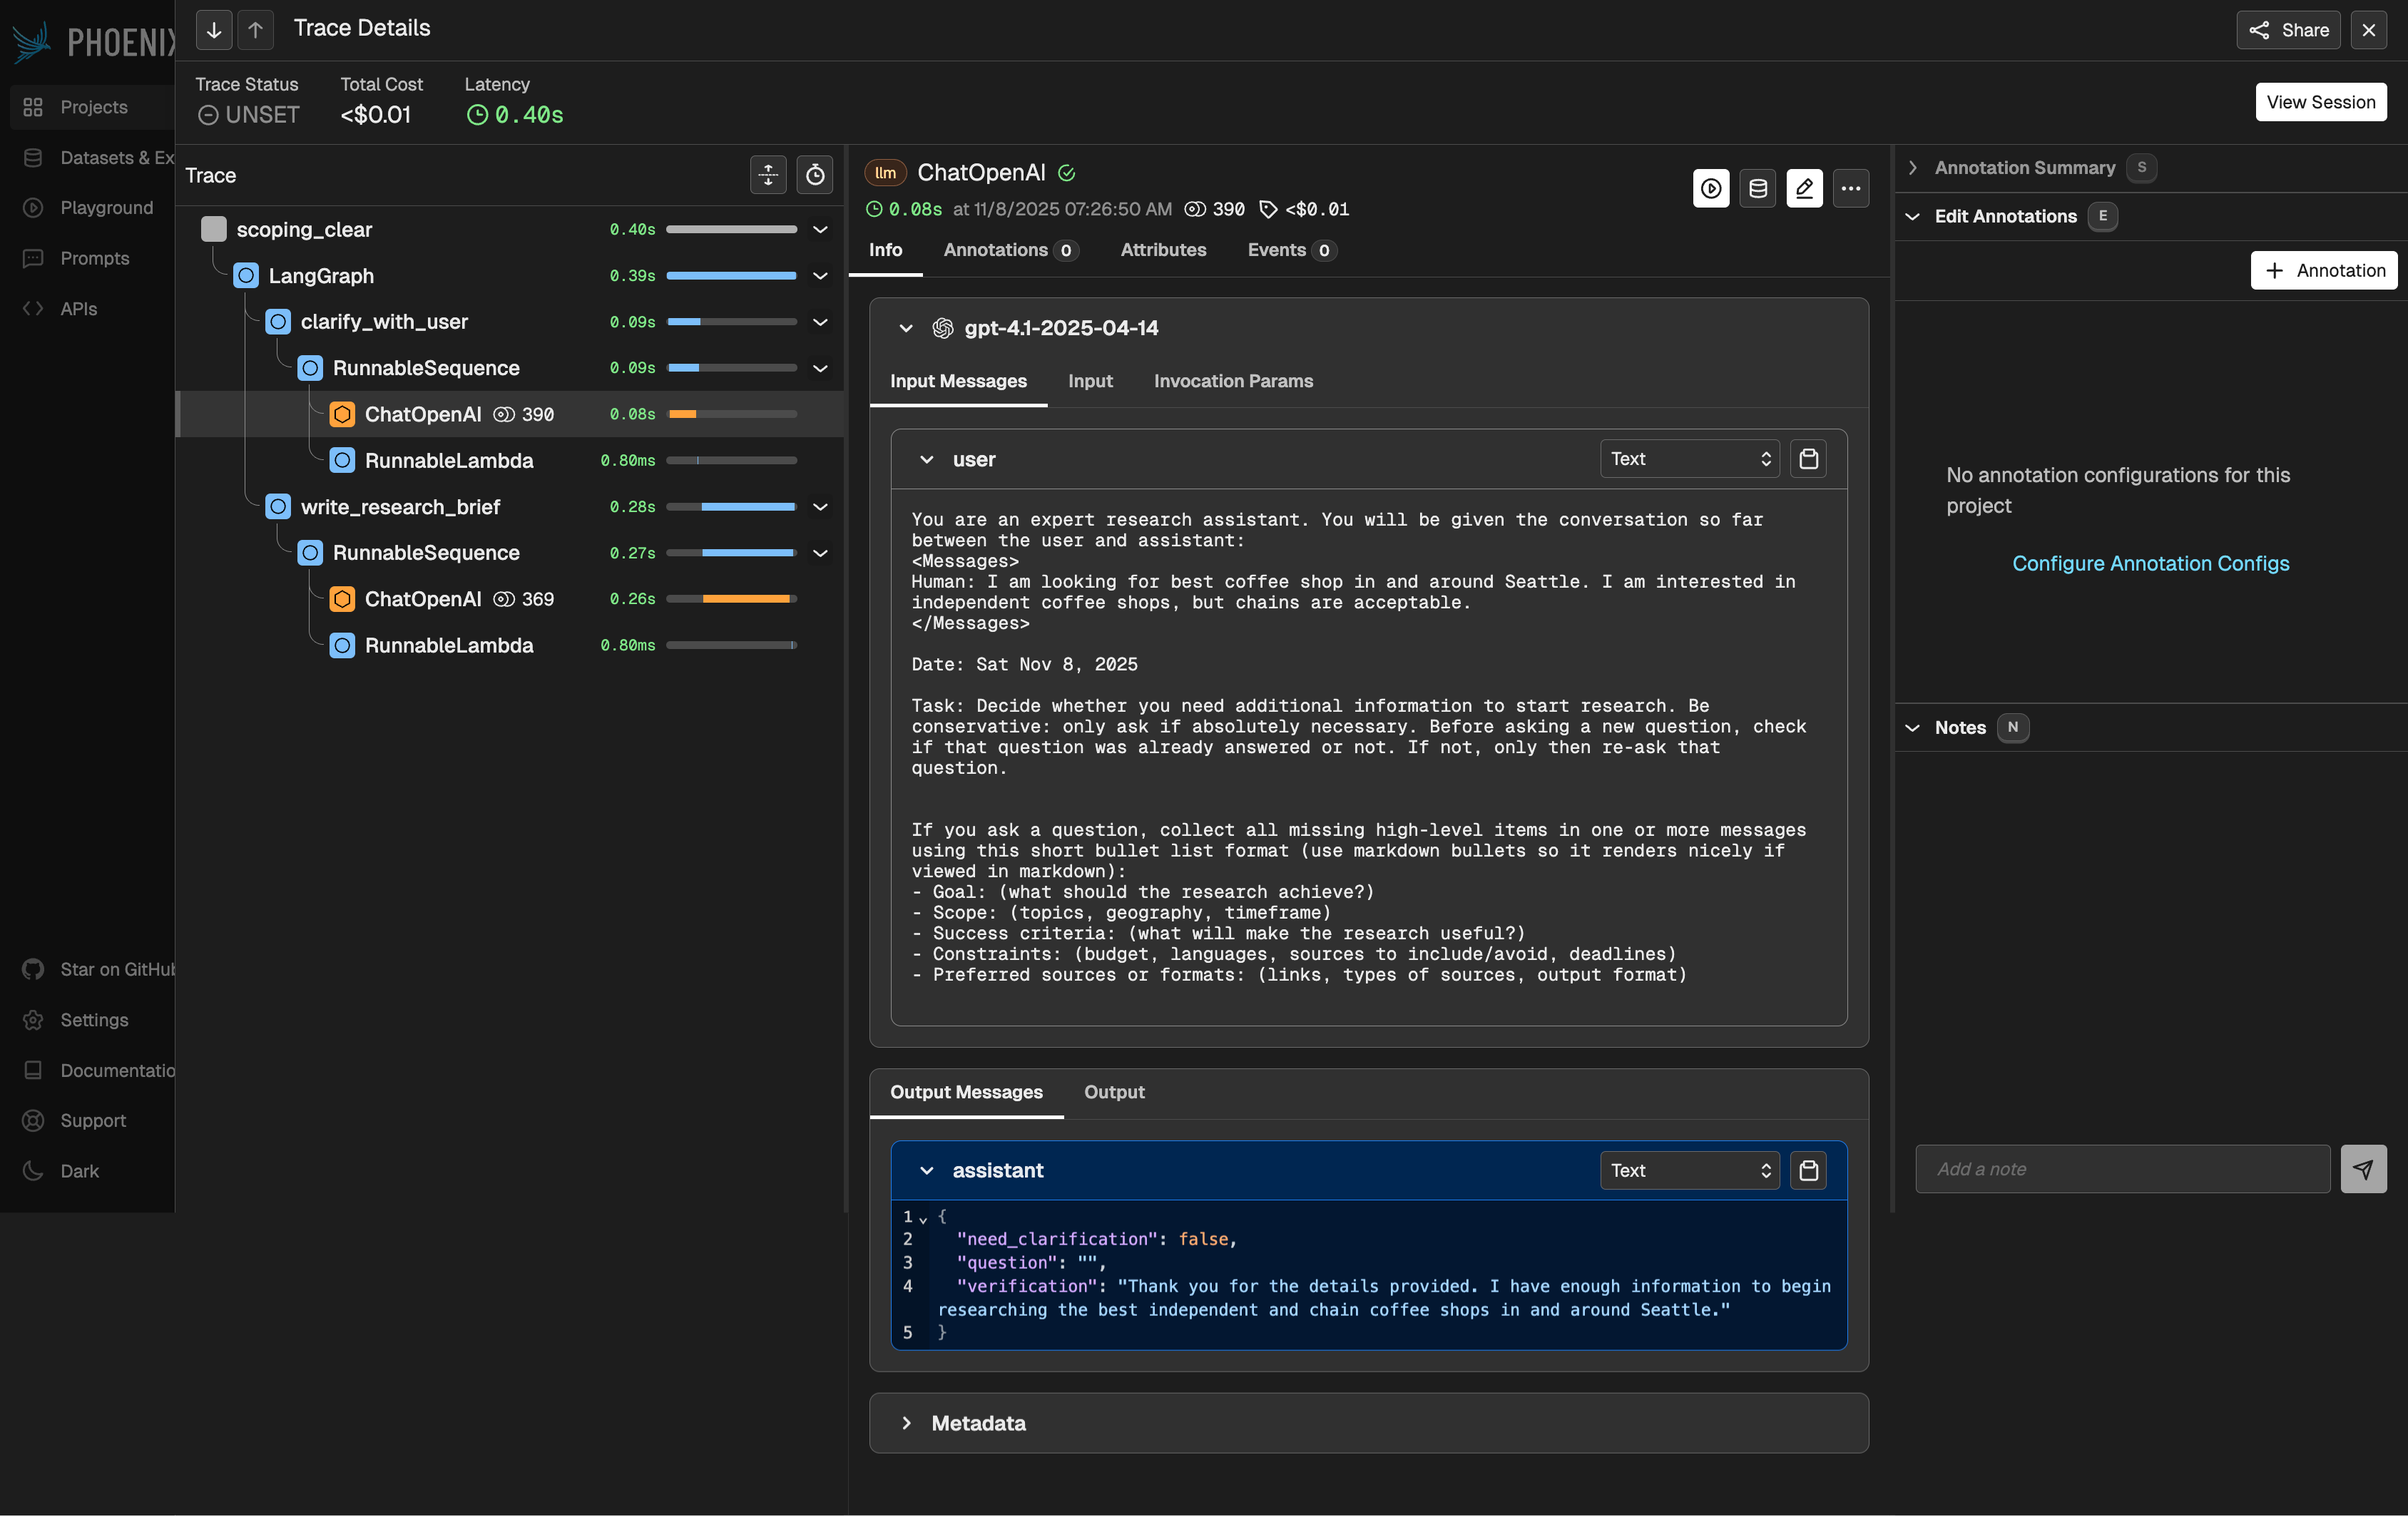

In [22]:
Image("../images/trace_scoping_clear.png")